# Wine Quality Prediction using Random Forest Regression

# Problem Statement

The quality of wine is influenced by several physicochemical properties such as acidity, sugar content, alcohol percentage, pH, density, and sulphates. Accurately predicting wine quality using these characteristics can help wineries improve quality control and production processes. The objective of this project is to build a Random Forest Regression model that predicts the quality score of red wine based on its physicochemical attributes. The project includes data preprocessing, exploratory data analysis (EDA), feature selection, hyperparameter tuning, and model evaluation to develop an accurate and reliable prediction model

# Data Structure

- The dataset consists of physicochemical properties of red wine samples. The objective is to analyze the relationship between these properties and predict the quality score of the wine using a machine learning regression model.

- Total Rows           : 1599
- Total Columns        : 12

- Independent Variables: fixed acidity,
                         volatile acidity,
                         citric acid,
                         residual sugar,
                         chlorides,
                         free sulfur dioxide,
                         total sulfur dioxide,
                         density,
                         pH,
                         sulphates,
                         alcohol

- Target Column        : quality

- Target Variable Type : Numerical (Quality Score)

- Problem Type         : Regression Problem

- Model Used           : Random Forest Regressor

# Imported Library

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

# Dataset Loaded

In [99]:
df=pd.read_csv('winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


# Data Understanding

In [100]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [101]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [103]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [104]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 1599
Number of columns: 12


In [105]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [106]:
for i in df.columns:
    print(f'Number of unique values in {i}: {df[i].nunique()}')

Number of unique values in fixed acidity: 96
Number of unique values in volatile acidity: 143
Number of unique values in citric acid: 80
Number of unique values in residual sugar: 91
Number of unique values in chlorides: 153
Number of unique values in free sulfur dioxide: 60
Number of unique values in total sulfur dioxide: 144
Number of unique values in density: 436
Number of unique values in pH: 89
Number of unique values in sulphates: 96
Number of unique values in alcohol: 65
Number of unique values in quality: 6


# Data Cleaning

In [107]:
df.duplicated().sum()

np.int64(240)

In [108]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [109]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

# Feature Engineering

In [110]:
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']


# Exploratory Data Analysis

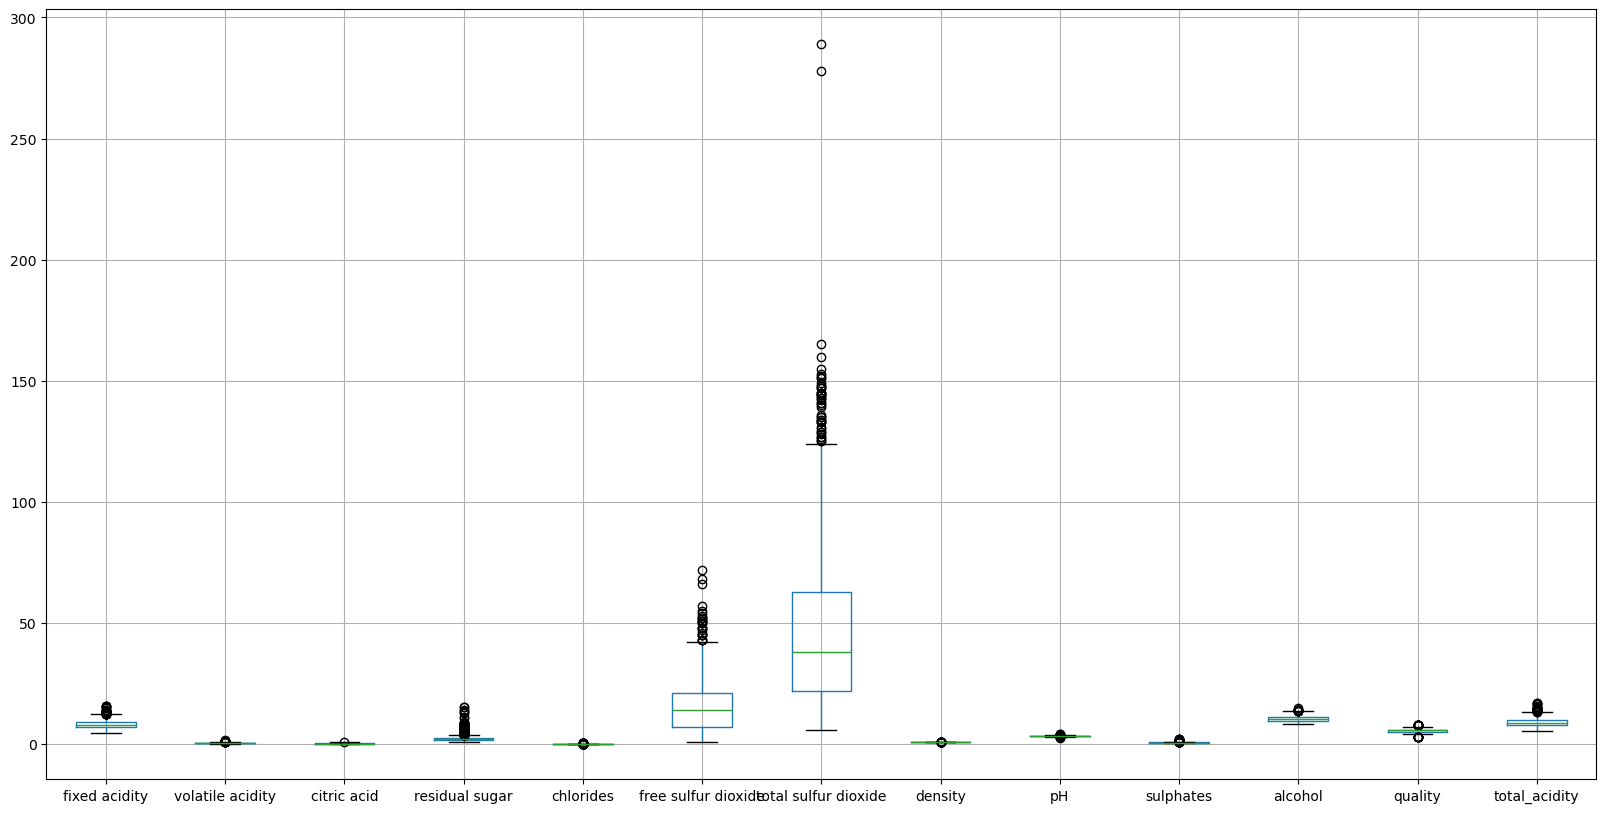

In [111]:
plt.figure(figsize=(20,10))
df.boxplot()
plt.show()

# Split X and y

In [112]:
X=df.drop(['quality'],axis=1)
y=df['quality']

# Train-Test Split

In [113]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# Feature Selection

In [114]:
dtr= DecisionTreeRegressor(random_state=42)
dtr.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [115]:
dtr_imp=pd.Series(dtr.feature_importances_,index=X.columns)
imp_col=dtr_imp.sort_values(ascending=False).head(9).index
imp_col

Index(['alcohol', 'sulphates', 'volatile acidity', 'pH',
       'total sulfur dioxide', 'chlorides', 'free sulfur dioxide',
       'citric acid', 'residual sugar'],
      dtype='object')

# Model Building

In [116]:
rd=RandomForestRegressor(random_state=42)
rd.fit(x_train[imp_col],y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prediction

In [117]:
yp=rd.predict(x_test[imp_col])
yp

array([4.96, 5.9 , 6.51, 5.31, 5.35, 6.81, 5.62, 5.15, 5.93, 5.62, 6.72,
       5.94, 5.72, 5.5 , 6.15, 5.01, 5.99, 5.12, 4.96, 6.14, 5.12, 6.14,
       5.06, 4.86, 5.52, 5.05, 5.91, 5.56, 5.28, 5.81, 6.18, 6.1 , 5.71,
       4.93, 5.23, 6.42, 4.95, 6.05, 5.45, 5.96, 4.74, 5.51, 6.02, 4.97,
       5.64, 5.46, 5.08, 5.03, 5.38, 6.2 , 5.88, 6.63, 6.61, 5.44, 6.2 ,
       5.03, 5.61, 5.16, 5.29, 5.38, 5.08, 6.11, 5.29, 6.38, 5.31, 6.09,
       5.06, 5.27, 5.76, 6.34, 5.26, 7.24, 5.87, 5.88, 5.88, 5.2 , 5.18,
       5.5 , 5.33, 5.26, 5.96, 5.74, 5.39, 5.2 , 5.43, 6.02, 5.41, 5.07,
       5.86, 5.84, 5.99, 4.87, 4.77, 5.65, 5.95, 5.73, 4.7 , 6.96, 6.07,
       5.13, 4.96, 4.89, 5.25, 5.62, 5.74, 5.36, 5.9 , 6.62, 6.62, 6.55,
       5.74, 5.53, 5.19, 5.42, 5.15, 5.61, 4.83, 5.29, 5.25, 6.27, 5.16,
       5.37, 5.76, 5.89, 5.54, 5.29, 5.08, 5.12, 5.65, 5.28, 5.51, 5.3 ,
       5.7 , 5.88, 5.06, 4.45, 6.48, 5.67, 6.11, 5.19, 5.42, 5.09, 6.54,
       5.52, 5.76, 6.14, 5.78, 5.68, 5.77, 5.53, 5.

# Evaluation

In [118]:
mse=mean_squared_error(y_test,yp)
mae=mean_absolute_error(y_test,yp)
print(f'Mean_squared_error: {mse}')
print(f'Root_mean_squared_error: {np.sqrt(mse)}')
print(f'Mean_absolute_error: {mae}')
print(f'R2_score: {r2_score(y_test,yp)}')

Mean_squared_error: 0.3861716911764706
Root_mean_squared_error: 0.6214271406822127
Mean_absolute_error: 0.47011029411764704
R2_score: 0.45483377411414505


# Hyperparamter Tuning

In [119]:
params={
    'n_estimators':[60,70,75,80],
    'max_depth': [5,6,4,3,7,9,8],
    'min_samples_split':[2,3,4,5]
}
params

{'n_estimators': [60, 70, 75, 80],
 'max_depth': [5, 6, 4, 3, 7, 9, 8],
 'min_samples_split': [2, 3, 4, 5]}

In [120]:
grid=GridSearchCV(RandomForestRegressor(random_state=42),param_grid=params,verbose=1)

In [121]:
grid.fit(x_train[imp_col],y_train)

Fitting 5 folds for each of 112 candidates, totalling 560 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [60, 70, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,75


In [122]:
grid.best_params_

{'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 75}

# Model Building with Best params

In [123]:
rd=RandomForestRegressor(random_state=42,max_depth=7,min_samples_split=4,n_estimators=75)
rd.fit(x_train[imp_col],y_train)

,n_estimators,75
,criterion,'squared_error'
,max_depth,7
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
yp=rd.predict(x_test[imp_col])
yp

array([5.07767746, 5.84414959, 6.51193087, 5.27910308, 5.29368202,
       6.79417531, 5.64354784, 5.07880717, 5.9362965 , 5.51742583,
       6.69662103, 5.88623907, 5.93022917, 5.41830115, 6.20498353,
       5.08728341, 6.07336576, 5.17582244, 5.04473703, 6.1929094 ,
       5.16089733, 5.99051608, 5.10871115, 4.958727  , 5.54848241,
       5.12390076, 5.80016679, 5.47349472, 5.36313121, 5.67118197,
       6.00933488, 6.02918029, 5.62888107, 4.94662268, 5.31122275,
       6.35921037, 5.04069687, 5.98738677, 5.51936592, 6.00978001,
       4.91273511, 5.6492505 , 5.9712921 , 5.02456583, 5.53468099,
       5.30923856, 5.04706292, 4.98819071, 5.2685158 , 6.05754339,
       5.81695052, 6.61368931, 6.49684441, 5.52595515, 6.2315848 ,
       5.12342638, 5.35133123, 5.16455184, 5.28060595, 5.76365424,
       5.11436423, 6.09624391, 5.37351805, 6.33719924, 5.47480064,
       5.99085962, 5.11214827, 5.20298629, 5.93871723, 6.33498719,
       5.15343063, 6.96869449, 5.88309217, 6.02091506, 5.76395

In [125]:
mse=mean_squared_error(y_test,yp)
mae=mean_absolute_error(y_test,yp)
print(f'Mean_squared_error: {mse}')
print(f'Root_mean_squared_error: {np.sqrt(mse)}')
print(f'Mean_absolute_error: {mae}')
print(f'R2_score: {r2_score(y_test,yp)}')

Mean_squared_error: 0.3768129503223001
Root_mean_squared_error: 0.6138509186458061
Mean_absolute_error: 0.4667911857355231
R2_score: 0.46804569395987083


In [126]:
rd.score(x_train[imp_col],y_train),rd.score(x_test[imp_col],y_test)

(0.6790508359378757, 0.46804569395987083)